In [23]:
import pandas as pd
import numpy as np
from pathlib import Path

results_dir = Path("../results")

csv_files = sorted(results_dir.glob("*.csv"), key=lambda p: p.stat().st_mtime)
print("Found CSV:", len(csv_files))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {results_dir.resolve()}")

latest_csv = csv_files[-1]
print("Using:", latest_csv)

df = pd.read_csv(latest_csv)
df.head()

Found CSV: 1
Using: ../results/hll_20260211_203652.csv


,stream_id,step,processed,true_unique,estimate,algo,b_or_p,m,seed
0,0,0,1000,992,1017.790055,hll,10,1024,42
1,0,0,1000,992,992.014664,hllpp,10,1024,42
2,0,1,2000,1968,1966.936588,hll,10,1024,42
3,0,1,2000,1968,1968.057715,hllpp,10,1024,42
4,0,2,4000,3924,3788.933931,hll,10,1024,42


In [24]:
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

display(df.dtypes)

required = {"stream_id", "step", "processed", "true_unique", "estimate"}
missing = required - set(df.columns)
print("Missing required columns:", missing)

num_cols = ["processed", "true_unique", "estimate"]
bad = {}
for c in num_cols:
    bad[c] = {
        "nan": int(df[c].isna().sum()),
        "inf": int(np.isinf(df[c]).sum()),
        "min": float(np.nanmin(df[c])),
        "max": float(np.nanmax(df[c])),
    }
bad

Rows: 200
Columns: ['stream_id', 'step', 'processed', 'true_unique', 'estimate', 'algo', 'b_or_p', 'm', 'seed']


stream_id        int64
step             int64
processed        int64
true_unique      int64
estimate       float64
algo               str
b_or_p           int64
m                int64
seed             int64
dtype: object

Missing required columns: set()


{'processed': {'nan': 0, 'inf': 0, 'min': 1000.0, 'max': 20000.0},
 'true_unique': {'nan': 0, 'inf': 0, 'min': 988.0, 'max': 19406.0},
 'estimate': {'nan': 0, 'inf': 0, 'min': 929.816794, 'max': 20994.244944}}

In [25]:
df = df.copy()
df["abs_err"] = (df["estimate"] - df["true_unique"]).abs()
df["rel_err"] = df["abs_err"] / df["true_unique"].replace(0, np.nan)

print("Unique algos:", df["algo"].unique() if "algo" in df.columns else "(no algo column)")

df.groupby("step")[["processed", "true_unique", "estimate", "rel_err"]].agg(["mean", "std"]).head()

Unique algos: <StringArray>
['hll', 'hllpp']
Length: 2, dtype: str


processed      true_unique                 estimate              \
          mean  std        mean        std          mean         std   
step                                                                   
0       1000.0  0.0      993.00   2.952617    992.899451   16.719773   
1       2000.0  0.0     1973.40   6.432290   1982.057219   43.060648   
2       4000.0  0.0     3919.10   8.851481   3929.597061   95.849016   
3      10000.0  0.0     9711.45  17.259631   9690.831310  333.594470   
4      20000.0  0.0    19341.05  23.335842  19347.521272  629.010723   

       rel_err            
          mean       std  
step                      
0     0.008924  0.013314  
1     0.012453  0.017829  
2     0.013632  0.020461  
3     0.026838  0.021358  
4     0.024975  0.020517

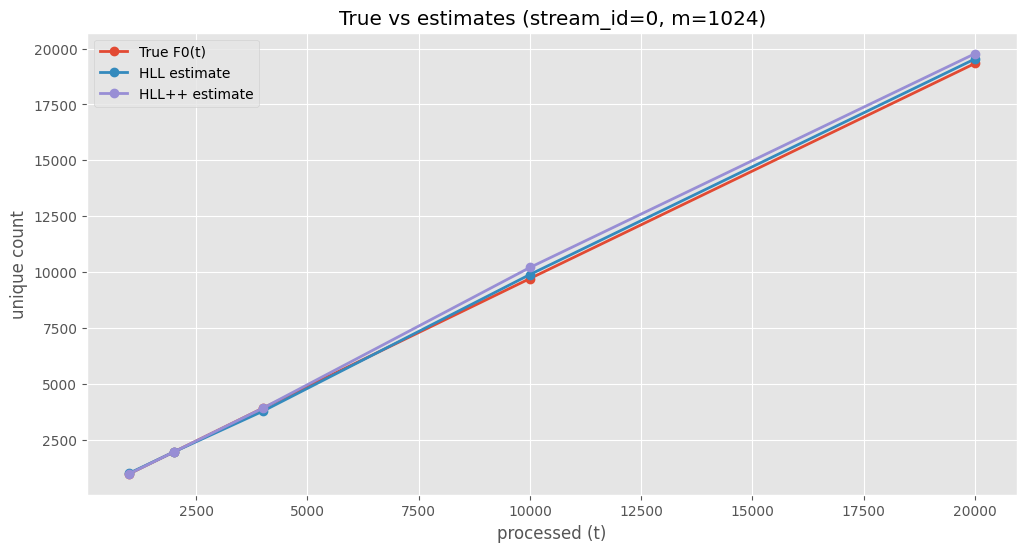

In [26]:
import matplotlib.pyplot as plt

sid = 0
d = df[df["stream_id"] == sid].sort_values(["processed", "algo"])

true_line = d.drop_duplicates("processed")[["processed", "true_unique"]].sort_values("processed")

hll_line   = d[d["algo"] == "hll"][["processed", "estimate"]].sort_values("processed")
hllpp_line = d[d["algo"] == "hllpp"][["processed", "estimate"]].sort_values("processed")

plt.figure()
plt.plot(true_line["processed"], true_line["true_unique"], marker="o", label="True F0(t)")
plt.plot(hll_line["processed"], hll_line["estimate"], marker="o", label="HLL estimate")
plt.plot(hllpp_line["processed"], hllpp_line["estimate"], marker="o", label="HLL++ estimate")
plt.xlabel("processed (t)")
plt.ylabel("unique count")
plt.title(f"True vs estimates (stream_id={sid}, m={int(d['m'].iloc[0])})")
plt.grid(True)
plt.legend()
plt.show()

Оценки HLL и HLL++ близки к истинному числу уникальных элементов.

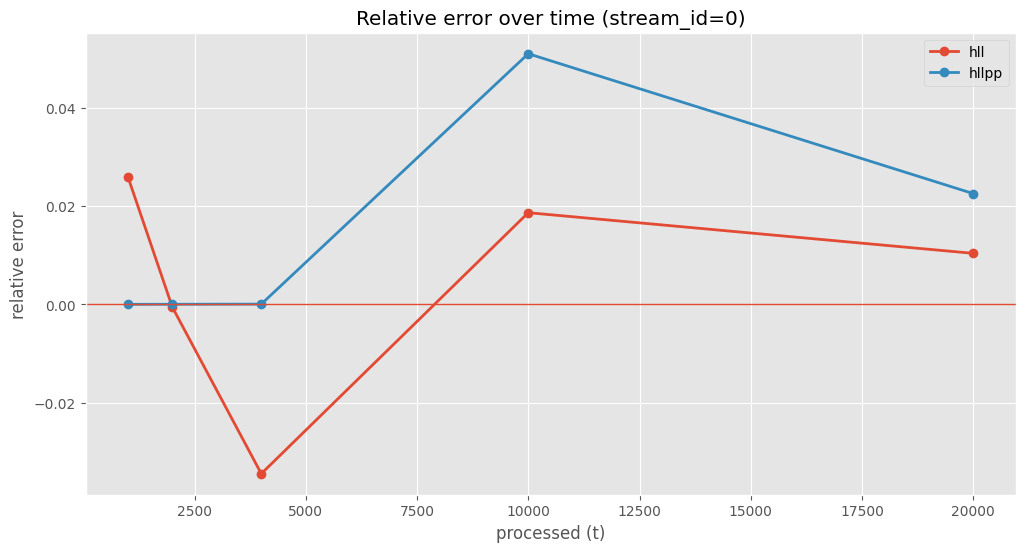

In [27]:
import matplotlib.pyplot as plt

sid = 0
d = df[df["stream_id"] == sid].sort_values(["processed", "algo"])
true_line = d.drop_duplicates("processed")[["processed", "true_unique"]].sort_values("processed")

def rel_err_line(algo):
    x = d[d["algo"] == algo].sort_values("processed")
    y = (x["estimate"].values - x["true_unique"].values) / x["true_unique"].values
    return x["processed"].values, y

plt.figure()
for algo in ["hll", "hllpp"]:
    xs, ys = rel_err_line(algo)
    plt.plot(xs, ys, marker="o", label=algo)

plt.axhline(0, linewidth=1)
plt.xlabel("processed (t)")
plt.ylabel("relative error")
plt.title(f"Relative error over time (stream_id={sid})")
plt.grid(True)
plt.legend()
plt.show()

Относительная ошибка колеблется вокруг нуля. На отдельных потоках HLL++ может быть хуже/лучше HLL - это ожидаемо из-за случайности алгоритма. Поэтому по одному потоку качество нельзя оцениваеть.

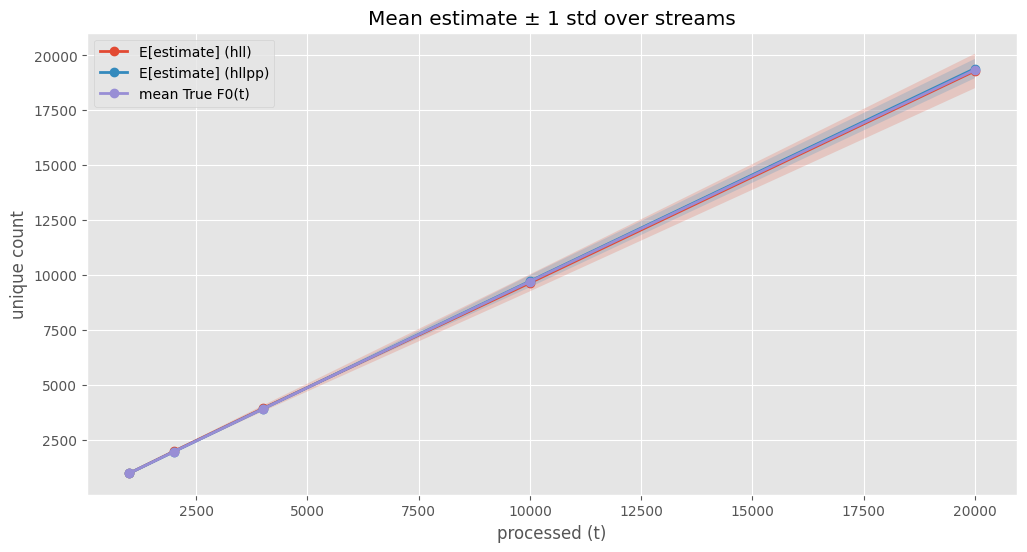

,algo,processed,true_unique,mean_est,std_est
0,hll,1000,993.00,992.834210,23.774546
1,hll,2000,1973.40,1990.706408,60.048916
2,hll,4000,3919.10,3939.965242,136.197997
3,hll,10000,9711.45,9652.439211,386.529029
4,hll,20000,19341.05,19292.601182,783.539353
5,hllpp,1000,993.00,992.964692,2.928621
6,hllpp,2000,1973.40,1973.408030,6.531887
7,hllpp,4000,3919.10,3919.228879,9.021498
8,hllpp,10000,9711.45,9729.223409,275.535679
9,hllpp,20000,19341.05,19402.441362,438.005770


In [28]:
import matplotlib.pyplot as plt

agg = (df
       .groupby(["algo", "processed"], as_index=False)
       .agg(true_unique=("true_unique", "mean"),
            mean_est=("estimate", "mean"),
            std_est=("estimate", "std")))

plt.figure()
for algo in ["hll", "hllpp"]:
    a = agg[agg["algo"] == algo].sort_values("processed")
    plt.plot(a["processed"], a["mean_est"], marker="o", label=f"E[estimate] ({algo})")
    plt.fill_between(a["processed"],
                     a["mean_est"] - a["std_est"],
                     a["mean_est"] + a["std_est"],
                     alpha=0.2)

true_mean = agg.drop_duplicates("processed")[["processed", "true_unique"]].sort_values("processed")
plt.plot(true_mean["processed"], true_mean["true_unique"], marker="o", linewidth=2, label="mean True F0(t)")

plt.xlabel("processed (t)")
plt.ylabel("unique count")
plt.title("Mean estimate ± 1 std over streams")
plt.grid(True)
plt.legend()
plt.show()

agg

В среднем обе оценки близки к истинному значению, но у HLL++ заметно меньше стандартное отклонение (выше стабильность), особенно на малых t.

m = 1024
theory 1.04/sqrt(m) = 0.0325
theory 1.30/sqrt(m) = 0.040625


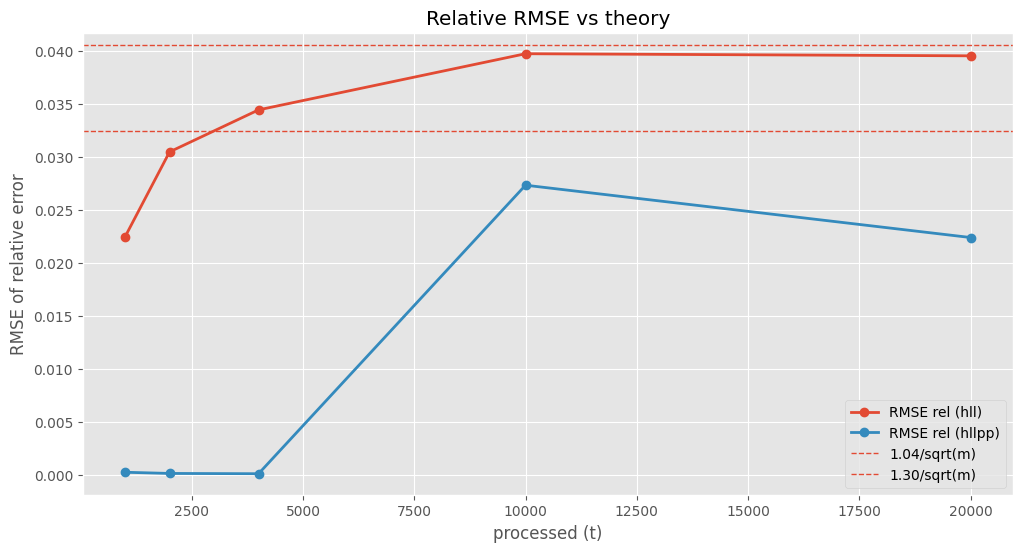

,algo,processed,rmse_rel,mean_rel,std_rel
0,hll,1000,0.022470,-0.000182,0.023053
1,hll,2000,0.030495,0.008760,0.029969
2,hll,4000,0.034468,0.005331,0.034938
3,hll,10000,0.039776,-0.006055,0.040333
4,hll,20000,0.039577,-0.002504,0.040524
5,hllpp,1000,0.000221,-0.000035,0.000224
6,hllpp,2000,0.000111,0.000004,0.000113
7,hllpp,4000,0.000083,0.000033,0.000079
8,hllpp,10000,0.027350,0.001821,0.027998
9,hllpp,20000,0.022406,0.003177,0.022756


In [29]:
import numpy as np
import matplotlib.pyplot as plt

m = int(df["m"].iloc[0])
theory_104 = 1.04 / np.sqrt(m)
theory_13  = 1.30 / np.sqrt(m)
print("m =", m)
print("theory 1.04/sqrt(m) =", theory_104)
print("theory 1.30/sqrt(m) =", theory_13)

tmp = df.copy()
tmp["rel_err_signed"] = (tmp["estimate"] - tmp["true_unique"]) / tmp["true_unique"]

rmse = (tmp
        .groupby(["algo", "processed"], as_index=False)
        .agg(rmse_rel=("rel_err_signed", lambda x: np.sqrt(np.mean(np.square(x)))),
             mean_rel=("rel_err_signed", "mean"),
             std_rel=("rel_err_signed", "std")))

plt.figure()
for algo in ["hll", "hllpp"]:
    a = rmse[rmse["algo"] == algo].sort_values("processed")
    plt.plot(a["processed"], a["rmse_rel"], marker="o", label=f"RMSE rel ({algo})")

plt.axhline(theory_104, linestyle="--", linewidth=1, label="1.04/sqrt(m)")
plt.axhline(theory_13,  linestyle="--", linewidth=1, label="1.30/sqrt(m)")
plt.xlabel("processed (t)")
plt.ylabel("RMSE of relative error")
plt.title("Relative RMSE vs theory")
plt.grid(True)
plt.legend()
plt.show()

rmse

Для HLL RMSE на больших t лежит между оценками 1.04/sqrt{m} и 1.30/sqrt{m}, т.е. соответствует с теории. HLL++ даёт меньшую RMSE (особенно на малых t за счёт коррекций) и на больших t остаётся лучше HLL.

In [30]:
summary = (rmse
           .pivot(index="processed", columns="algo", values=["rmse_rel", "mean_rel", "std_rel"])
           .sort_index())
summary

rmse_rel            mean_rel             std_rel          
algo            hll     hllpp       hll     hllpp       hll     hllpp
processed                                                            
1000       0.022470  0.000221 -0.000182 -0.000035  0.023053  0.000224
2000       0.030495  0.000111  0.008760  0.000004  0.029969  0.000113
4000       0.034468  0.000083  0.005331  0.000033  0.034938  0.000079
10000      0.039776  0.027350 -0.006055  0.001821  0.040333  0.027998
20000      0.039577  0.022406 -0.002504  0.003177  0.040524  0.022756

HLL имеет RMSE около 4% на больших t и заметный разброс. HLL++ даёт существенно меньший RMSE и дисперсию.

In [31]:
impr = rmse.pivot(index="processed", columns="algo", values="rmse_rel").copy()
impr["improvement_%"] = 100.0 * (impr["hll"] - impr["hllpp"]) / impr["hll"]
impr

algo,hll,hllpp,improvement_%
processed,,,
1000,0.022470,0.000221,99.014513
2000,0.030495,0.000111,99.637305
4000,0.034468,0.000083,99.758027
10000,0.039776,0.027350,31.239171
20000,0.039577,0.022406,43.385135


Улучшение HLL++ по RMSE составляет ~99% на малых t (за счёт LC/коррекций) и остаётся значимым на больших t: ~31% при t=10000 и ~43% при t=20000.

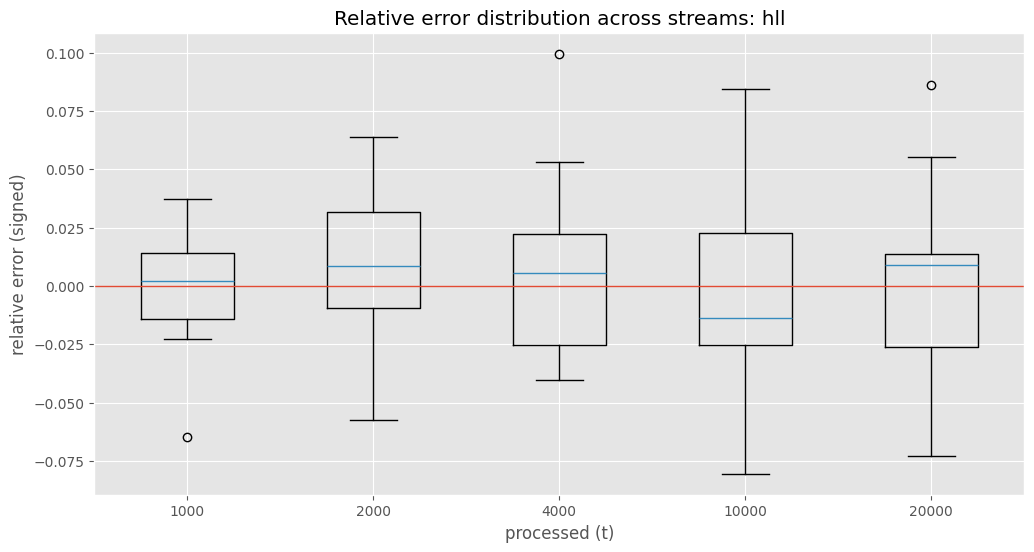

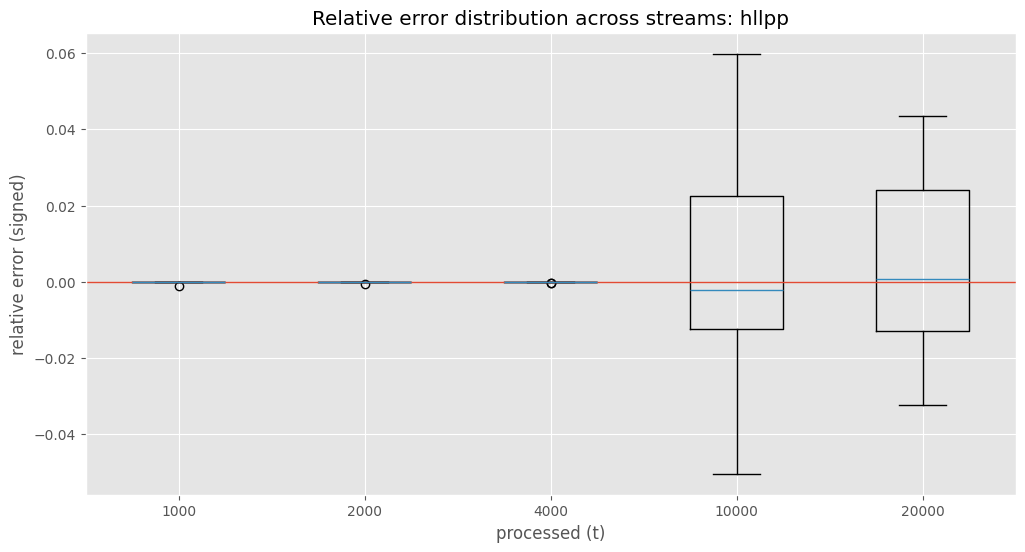

In [33]:
import matplotlib.pyplot as plt

tmp = df.copy()
tmp["rel_err_signed"] = (tmp["estimate"] - tmp["true_unique"]) / tmp["true_unique"]

for algo in ["hll", "hllpp"]:
    plt.figure()
    data = []
    labels = []
    for t in sorted(tmp["processed"].unique()):
        vals = tmp[(tmp["algo"] == algo) & (tmp["processed"] == t)]["rel_err_signed"].values
        data.append(vals)
        labels.append(str(int(t)))
    plt.boxplot(data, tick_labels=labels, showfliers=True)
    plt.axhline(0, linewidth=1)
    plt.xlabel("processed (t)")
    plt.ylabel("relative error (signed)")
    plt.title(f"Relative error distribution across streams: {algo}")
    plt.grid(True, axis="y")
    plt.show()

Ошибка HLL имеет заметный разброс по потокам и присутствуют выбросы. Дисперсия растёт с t и остаётся существенной даже на больших объёмах. В то время HLL++, на малых t распределение ошибок около нуля, на больших t разброс появляется, но остаётся меньше, чем у HLL.

In [35]:
from pathlib import Path
import pandas as pd
import numpy as np

results_dir = Path("../results") if Path("../results").exists() else Path("results")
csv_files = sorted(results_dir.glob("*.csv"), key=lambda p: p.stat().st_mtime)

lastN = 3
picked = csv_files[-lastN:]
print("Picked files:")
for p in picked:
    print(" -", p.name)

dfs = []
for p in picked:
    d = pd.read_csv(p)
    d["source_file"] = p.name
    dfs.append(d)

df_all = pd.concat(dfs, ignore_index=True)

df_all["rel_err_signed"] = (df_all["estimate"] - df_all["true_unique"]) / df_all["true_unique"]

df_all[["source_file","algo","b_or_p","m"]].drop_duplicates().sort_values(["algo","b_or_p"])

Picked files:
 - hll_20260211_205207.csv
 - hll_20260211_205210.csv
 - hll_20260211_205212.csv


,source_file,algo,b_or_p,m
0,hll_20260211_205207.csv,hll,8,256
200,hll_20260211_205210.csv,hll,10,1024
400,hll_20260211_205212.csv,hll,12,4096
1,hll_20260211_205207.csv,hllpp,8,256
201,hll_20260211_205210.csv,hllpp,10,1024
401,hll_20260211_205212.csv,hllpp,12,4096


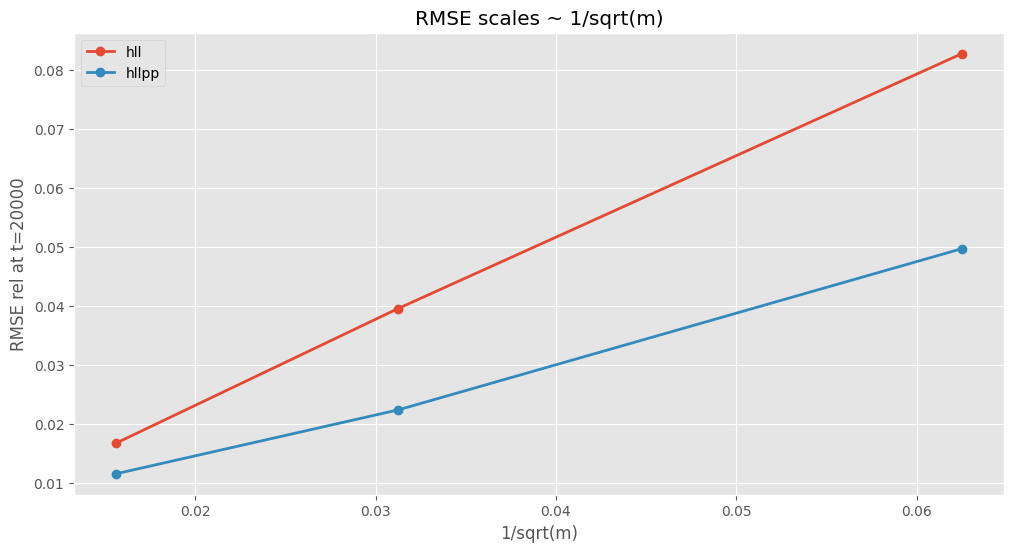

,algo,m,rmse_rel,mean_rel,std_rel,inv_sqrt_m
0,hll,256,0.082735,-0.014288,0.083609,0.062500
3,hllpp,256,0.049711,0.013954,0.048952,0.062500
1,hll,1024,0.039577,-0.002504,0.040524,0.031250
4,hllpp,1024,0.022406,0.003177,0.022756,0.031250
2,hll,4096,0.016793,0.000068,0.017229,0.015625
5,hllpp,4096,0.011595,0.000462,0.011887,0.015625


In [36]:
import matplotlib.pyplot as plt

Tmax = df_all["processed"].max()
sub = df_all[df_all["processed"] == Tmax].copy()

rmse_m = (sub.groupby(["algo","m"], as_index=False)
          .agg(rmse_rel=("rel_err_signed", lambda x: np.sqrt(np.mean(x*x))),
               mean_rel=("rel_err_signed","mean"),
               std_rel=("rel_err_signed","std")))

rmse_m = rmse_m.sort_values("m")
rmse_m["inv_sqrt_m"] = 1.0/np.sqrt(rmse_m["m"])

plt.figure()
for algo in ["hll","hllpp"]:
    a = rmse_m[rmse_m["algo"] == algo]
    plt.plot(a["inv_sqrt_m"], a["rmse_rel"], marker="o", label=algo)

plt.xlabel("1/sqrt(m)")
plt.ylabel(f"RMSE rel at t={int(Tmax)}")
plt.title("RMSE scales ~ 1/sqrt(m)")
plt.grid(True)
plt.legend()
plt.show()

rmse_m

Для обоих алгоритмов RMSE убывает примерно как 1\sqrt{m} при увеличении точности b (рост m), что соответствует теоретической зависимости. При одинаковом m HLL++ демонстрирует меньшую RMSE.

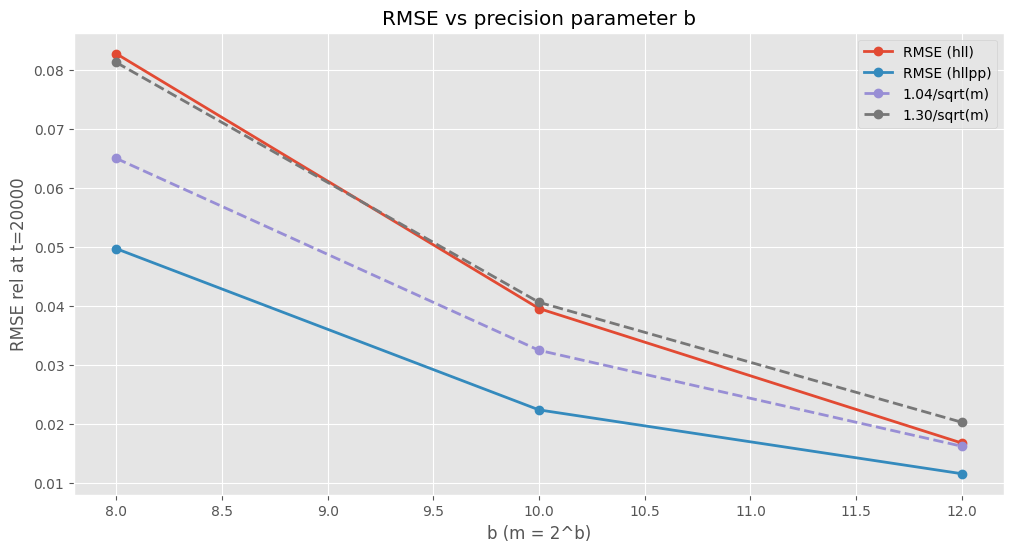

In [37]:
import matplotlib.pyplot as plt
import numpy as np

rmse_m2 = rmse_m.copy()
rmse_m2["b"] = np.log2(rmse_m2["m"]).astype(int)

rmse_m2["theory_104"] = 1.04 / np.sqrt(rmse_m2["m"])
rmse_m2["theory_13"]  = 1.30 / np.sqrt(rmse_m2["m"])

plt.figure()
for algo in ["hll", "hllpp"]:
    a = rmse_m2[rmse_m2["algo"] == algo].sort_values("b")
    plt.plot(a["b"], a["rmse_rel"], marker="o", label=f"RMSE ({algo})")

a0 = rmse_m2[rmse_m2["algo"] == "hll"].sort_values("b")
plt.plot(a0["b"], a0["theory_104"], linestyle="--", marker="o", label="1.04/sqrt(m)")
plt.plot(a0["b"], a0["theory_13"],  linestyle="--", marker="o", label="1.30/sqrt(m)")

plt.xlabel("b (m = 2^b)")
plt.ylabel(f"RMSE rel at t={int(Tmax)}")
plt.title("RMSE vs precision parameter b")
plt.grid(True)
plt.legend()
plt.show()

Для HLL экспериментальные значения близки к теоретическим границам 1.04/sqrt{m} - 1.30/sqrt{m}. HLL++ располагается ниже этих линий, т.к. использует дополнительные коррекции (bias/LC), уменьшающие ошибку.

In [38]:
pivot = rmse_m.pivot(index="m", columns="algo", values="rmse_rel").copy()
pivot["improvement_%"] = 100 * (pivot["hll"] - pivot["hllpp"]) / pivot["hll"]
pivot

algo,hll,hllpp,improvement_%
m,,,
256,0.082735,0.049711,39.915761
1024,0.039577,0.022406,43.385135
4096,0.016793,0.011595,30.953309


## Вывод

Стандартный HyperLogLog реализован корректно: экспериментальная RMSE соответствует теоритической и убывает как 1/sqrt{m}. Реализация HyperLogLog++ (по публикации Google) даёт более стабильные оценки и меньшую RMSE, особенно на малых значениях благодаря LinearCounting и коррекции смещения, на больших объёмах данных также показывает улучшение относительно стандартного HLL.